# **Fraud Detection Using Machine Learning**

Introduction :This is a personal machine learning project that compares the performance of Logistic Regression, Random Forest, and Gradient Boosting on a credit card fraud detection task using the Kaggle Credit Card Fraud Detection dataset. The project covers the complete machine learning workflow, including data preprocessing, handling class imbalance, hyperparameter tuning, threshold optimization, model evaluation, and SHAP-based feature importance analysis to better understand which features have the greatest influence on the models' predictions.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import userdata
import os
import joblib
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/FraudDetectionProject/creditcard.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Exploration and cleaning**



1.   Data Exploration :





In [ ]:
print(np.shape(df))

(284807, 31)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28





   2.Handling missing values (*Nan*)



In [ ]:
np.sum(df.isnull())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df=df.dropna()
np.sum(df.isnull())

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0





3- handling duplicated values


In [ ]:
duplicated=df.duplicated().sum()
print("number of duplicated values : "+str(duplicated))
df[df.duplicated()]
df=df.drop_duplicates(keep='first')
print(df[df.duplicated()])# for cheking :)


number of duplicated values : 1081
Empty DataFrame
Columns: [Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Class]
Index: []

[0 rows x 31 columns]


4-Descriptive Statistics

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


5- Fraud cases analysis

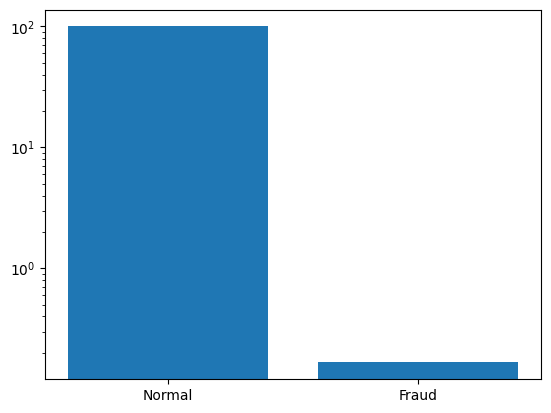

In [ ]:
# fraud cases vs normal
Class_analyze=np.array(df['Class'].value_counts(normalize=True)*100)
x=np.array(["Normal","Fraud"])
y=np.array([Class_analyze[0],Class_analyze[1]])
plt.bar(x,y)
plt.yscale('log')
plt.show()


6- Features and target separation

In [ ]:
features=df.drop('Class', axis=1)
Target=df['Class']


7-Explaining why Robust scaling is the best option



* histogram of the amount
*  comparing mean and median values


*   studying outliers using IQR method





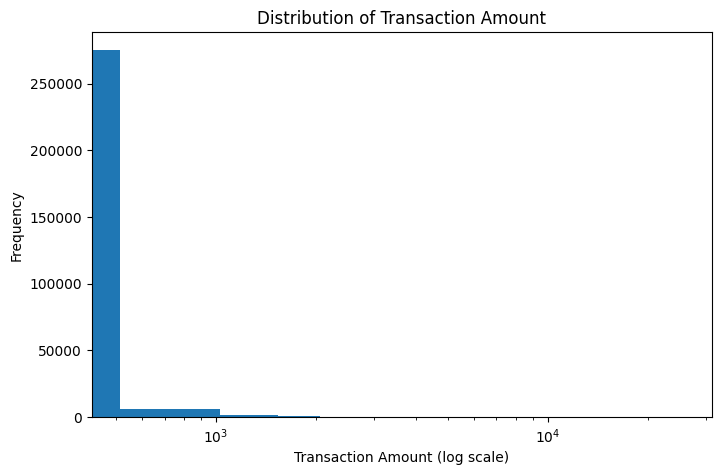

the mean of amount: 88.47268731099724
the median of amount: 22.0
the diffrence between mean and median :66.47268731099724
the percentage of outliers :11.1674643846528%


In [ ]:

#histogram of the amount
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.xscale("log")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")
plt.show()

#let's compare mean and median
mean=features["Amount"].mean()
print("the mean of amount: "+str(mean))
sorted_amount=np.sort(features["Amount"])
median=np.median(sorted_amount)
print("the median of amount: "+str(median))
diff=mean-median
print("the diffrence between mean and median :"+ str(diff))

#let's study outliers using IQR
Q1=features["Amount"].quantile(0.25)
Q3=features["Amount"].quantile(0.75)
lower_limit=Q1-1.5*(Q3-Q1)
upper_limit=Q3+1.5*(Q3-Q1)
percentage_of_outliers=(len(features[(features["Amount"]<lower_limit)|(features["Amount"]>upper_limit)])/len(features))*100
print("the percentage of outliers :"+ str(percentage_of_outliers) +"%" )



In [ ]:
# Applying Robustscaling to handle outliers and scale features
scaler=RobustScaler()
features=scaler.fit_transform(features)
features=pd.DataFrame(features)
features


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.995290,-0.618360,-0.097622,1.229434,0.880878,-0.218773,0.632648,0.176974,0.143677,0.335739,...,0.910319,0.026861,0.253199,-0.320939,0.032627,0.168017,-0.241512,0.816068,-0.246698,1.774718
1,-0.995290,0.524849,0.144367,-0.007034,0.295891,0.087159,0.165383,-0.106558,0.118241,-0.163546,...,-0.019525,-0.473668,-0.602596,0.363373,-0.479559,0.225835,0.314036,-0.064639,0.026214,-0.268530
2,-0.995279,-0.617709,-1.002505,0.831270,0.252882,-0.345402,1.780431,0.668400,0.422384,-1.178892,...,1.704013,0.669336,0.714327,2.974843,-0.919547,-0.514733,-0.153300,-0.351138,-0.541896,4.959811
3,-0.995279,-0.442046,-0.177906,0.841592,-0.529031,0.033147,1.305834,0.175202,0.665139,-1.075980,...,-0.422670,-0.190254,-0.001308,-0.578965,-1.531860,0.944541,-0.299382,0.378404,0.382702,1.411487
4,-0.995267,-0.528050,0.581026,0.714142,0.267510,-0.271669,0.318307,0.491620,-0.547078,0.701771,...,1.366197,0.048275,0.739164,-0.408139,0.126231,-0.332690,0.977848,1.346586,1.555108,0.667362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,1.035258,-5.332169,7.145374,-5.225152,-1.285968,-4.078964,-2.000020,-4.415983,13.625815,1.586057,...,4.462686,0.585997,0.098221,3.314371,-0.692986,2.126054,0.532968,5.821307,6.197405,-0.295230
283722,1.035270,-0.337440,-0.084985,0.967874,-0.450591,0.707883,1.143898,-0.014720,0.510672,0.513947,...,0.353866,0.587809,0.856915,0.076334,-1.331217,-0.932275,-0.605059,0.413928,-0.494416,0.038798
283723,1.035282,0.850880,-0.260747,-1.789381,-0.336889,2.061355,2.836132,-0.300704,1.284337,0.391107,...,0.184954,0.630848,0.533691,-0.085126,0.754375,0.373368,-0.062077,0.018389,-0.288712,0.638020
283724,1.035282,-0.116856,0.333095,0.272637,0.447890,-0.249218,0.771022,-0.647418,1.229575,0.358558,...,0.550624,0.710945,0.740817,-0.491641,0.103488,-0.876203,1.056109,0.663224,0.711284,-0.166875


8-Correlation between features and target

In [ ]:

#Analyzing linear relationship with the target
corelation=features.copy()
corelation["Class"]=Target
class_corr=corelation.corr()
class_corr=class_corr["Class"].sort_values(ascending=False)
class_corr


,Class
Class,1.000000
14,0.012895
13,0.012858
9,0.009471
11,0.008508
17,0.003797
3,0.003422
25,0.002727
4,0.002539
18,0.002493


9-Data splitting  &  Handling imbalance with BorderLineSmote

In [ ]:
# spliting data
x_train,x_test,y_train,y_test=train_test_split(features,Target, test_size=0.20, random_state=42,shuffle=True,stratify=Target)




In [ ]:
# applying  BorderlineSMOTE
print("before BorderlineSMOTE: "+str(y_train.value_counts()))
sm=BorderlineSMOTE(sampling_strategy="auto",random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)
print()
print("after BorderlineSMOTE : "+str(y_train.value_counts()))

before BorderlineSMOTE: Class
0    226602
1       378
Name: count, dtype: int64

after BorderlineSMOTE : Class
0    226602
1    226602
Name: count, dtype: int64


In [ ]:
# justification for choosing BorderLineSmote:_highly imbalanced dataset
                                           # _fraud cases are rare and models need enough exepmles to learn from
                                           # the Borderlinesmote was applied only to the  training data not the testing data to prevent the data leakage

# *Models training(Logistic regression-Random Forest- Gradient boosting) & hyperparameters tuning *

1- Logistic Reggression




*   Hyperparameters tuning






In [ ]:

parameter_grid={"C":[0.001,0.01,0.1,1,10,100],
            "penalty":["l1","l2"],
            "solver":["liblinear"]}


In [ ]:


x_sample,_,y_sample,_=train_test_split(x_train,y_train,test_size=0.8,random_state=42,stratify=y_train)
random_search= RandomizedSearchCV(LogisticRegression(max_iter=1000),parameter_grid,cv=3)
random_search.fit(x_sample,y_sample)
print("the best parameters are : "+ str(random_search.best_params_))


the best parameters are : {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}




*  Model training and fixing the threshold value using precision_recall_curve



In [ ]:
final_regression=LogisticRegression(C=100,penalty="l2", solver='liblinear')
final_regression.fit(x_train,y_train)
y_predect=final_regression.predict(x_test)
y_prob=final_regression.predict_proba(x_test)[:,-1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
F1_score=2*(precision*recall)/(precision+recall)
best_index=np.argmax(F1_score)
best_treshold=thresholds[best_index]
print("the best treshold is : "+ str(best_treshold))

new_predictions=(y_prob>=best_treshold).astype(int)



the best treshold is : 0.999999642801796




*   Logistic regression evaluation




In [ ]:

print("Logistic regression evaluation : ")
accuracy=accuracy_score(y_test,new_predictions)
print("the score of accuracy is : "+ str(accuracy))
precision=precision_score(y_test,new_predictions)
print("the score of precision is : "+ str(precision))
recall=recall_score(y_test,new_predictions)
print("the score of recall is : "+ str(recall))
f1=f1_score(y_test,new_predictions)
print("the score of f1 is : "+ str(f1))


Logistic regression evaluation : 
the score of accuracy is : 0.999365594050682
the score of precision is : 0.8831168831168831
the score of recall is : 0.7157894736842105
the score of f1 is : 0.7906976744186046


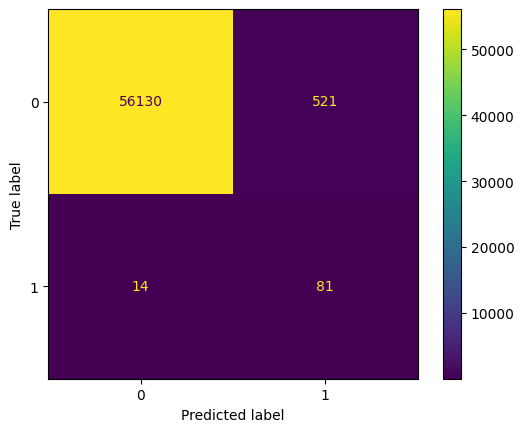

In [ ]:
ConfusionMatrixDisplay.from_predictions( y_test, y_predect)
plt.show()

2- Random Forest



*   hyperparameters tuning



In [ ]:
parameters2={"n_estimators":[10,35,50],
             "max_depth":[10,50,100],
             "min_samples_leaf":[2,10,30],
             "max_features":["sqrt","log2"],
             "criterion":["gini","entropy"]}

In [ ]:
x_sample2,_,y_sample2,_=train_test_split(x_train,y_train,test_size=0.8,random_state=42,stratify=y_train)
random_search2= RandomizedSearchCV(RandomForestClassifier(),parameters2,n_iter=3,cv=3)
random_search2.fit(x_sample2,y_sample2)
print("the best parameters are : "+ str(random_search2.best_params_))

the best parameters are : {'n_estimators': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 50, 'criterion': 'entropy'}




*   Model training and fixing threshold



In [ ]:
random_for= RandomForestClassifier(random_state=42,n_estimators=35,min_samples_leaf=2,max_features="sqrt",max_depth=10,criterion='gini')
random_for.fit(x_train,y_train)
y_predect2=random_for.predict(x_test)
y_prob2=random_for.predict_proba(x_test)[:,-1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob2)
F1_score2=2*(precision*recall)/(precision+recall)
best_index2=np.argmax(F1_score2)
best_treshold2=thresholds[best_index2]
print("the best treshold is : "+ str(best_treshold2))

new_predictions2=(y_prob2>=best_treshold2).astype(int)



the best treshold is : 0.7381034666195914




* Random Forest evaluation



In [ ]:
print(" Random Forest Evaluation: ")
accuracy2=accuracy_score(y_test,new_predictions2)
print("the score of accuracy is : "+ str(accuracy2))
precision2=precision_score(y_test,new_predictions2)
print("the score of precision is : "+ str(precision2))
recall2=recall_score(y_test,new_predictions2)
print("the score of recall is : "+ str(recall2))
f12=f1_score(y_test,new_predictions2)
print("the score of f1 is : "+ str(f12))


 Random Forest Evaluation: 
the score of accuracy is : 0.999365594050682
the score of precision is : 0.8641975308641975
the score of recall is : 0.7368421052631579
the score of f1 is : 0.7954545454545454


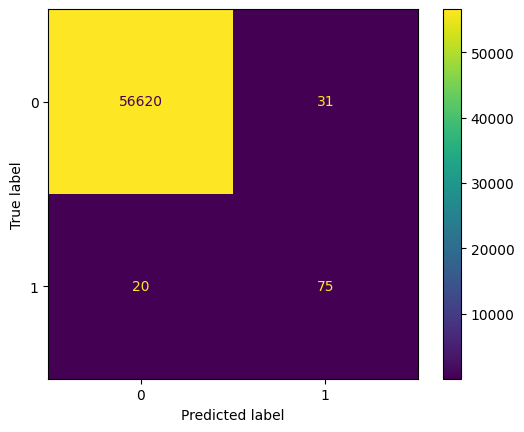

In [ ]:
ConfusionMatrixDisplay.from_predictions( y_test, y_predect2)
plt.show()

3-Gradient Boosting



*   Hyperparameters tuning



In [ ]:
#hyperparameters
parameters3={"loss":["log_loss","exponential"],
            "learning_rate":[0.1,0.2,0.5],
            "n_estimators":[10,35,50],
            "subsample":[0.5,0.8,1.0],
            "criterion":["friedman_mse","squared_error"],
            "min_samples_leaf":[2,10,30],
            "max_depth":[2,3,5],
            "max_features":["sqrt","log2"]
}

In [ ]:
x_sample3,_,y_sample3,_=train_test_split(x_train,y_train,test_size=0.8,random_state=42,stratify=y_train)
random_search3= RandomizedSearchCV(GradientBoostingClassifier(),parameters3,n_iter=3,cv=3)
random_search3.fit(x_sample3,y_sample3)
print("the best parameters are : "+ str(random_search3.best_params_))

the best parameters are : {'subsample': 0.8, 'n_estimators': 35, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 5, 'loss': 'log_loss', 'learning_rate': 0.2, 'criterion': 'friedman_mse'}






*   Model training and fixing threshold







In [ ]:
grediant_boosting=GradientBoostingClassifier(subsample=0.8,n_estimators=35,min_samples_leaf=30,max_features='sqrt',max_depth=5,loss="exponential",learning_rate=0.5,criterion='friedman_mse').fit(x_train,y_train)
y_predect3=grediant_boosting.predict(x_test)
y_proba3=grediant_boosting.predict_proba(x_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba3[:,-1])
F1_score3=2*(precision*recall)/(precision+recall)
best_index3=np.argmax(F1_score3)
best_treshold3=thresholds[best_index3]
print("the best treshold is : "+ str(best_treshold3))
new_predictions3=(y_proba3[:,-1]>=best_treshold3).astype(int)



the best treshold is : 0.9811701046810367




*  Gradient Boosting evaluation



In [ ]:
print("Gradient boosting evaluation :")
accuracy3=accuracy_score(y_test,new_predictions3)
print("the score of accuracy is : "+ str(accuracy3))
precision3=precision_score(y_test,new_predictions3)
print("the score of precision is : "+ str(precision3))
recall3=recall_score(y_test,new_predictions3)
print("the score of recall is : "+ str(recall3))
f13=f1_score(y_test,new_predictions3)
print("the score of f1 is : "+ str(f13))


Gradient boosting evaluation :
the score of accuracy is : 0.9994537059880872
the score of precision is : 0.9102564102564102
the score of recall is : 0.7473684210526316
the score of f1 is : 0.8208092485549133


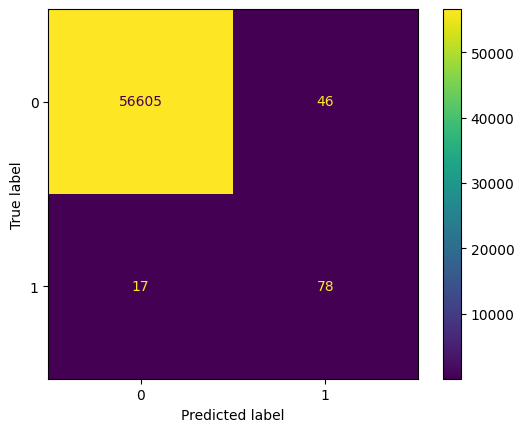

In [ ]:
confusion=ConfusionMatrixDisplay.from_predictions( y_test, y_predect3)
fig=confusion.figure_
plt.show()

In [ ]:
results_evaluations= pd.DataFrame(
    {
        "Model":["Logistic-Regression","Random-Forest","Grediant-boosting"],
        "Accuracy":[accuracy,accuracy2,accuracy3],
        "Precision":[precision,precision2,precision3],
        "Recall":[recall,recall2,recall3],
        "F1-score":[f1,f12,f13]
    }
)
print(results_evaluations)

                 Model  Accuracy  \
0  Logistic-Regression  0.999366   
1        Random-Forest  0.999366   
2    Grediant-boosting  0.999383   

                                           Precision  \
0  [0.0016741268107003137, 0.0016786231756016538,...   
1                                           0.864198   
2                                           0.848837   

                                              Recall  F1-score  
0  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...  0.790698  
1                                           0.736842  0.795455  
2                                           0.768421  0.806630  


## **Conclusion**: Gradient Boosting achieved the highest F1-score and recall among all the evaluated models, making it the best-performing model for this fraud detection task.


# **Features importance analysis using SHAP**

In [ ]:
explainer=shap.Explainer(grediant_boosting)
shap_values=explainer.shap_values(x_test)

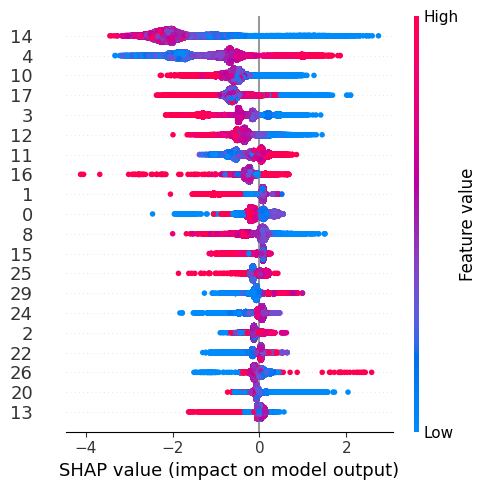

In [ ]:
shap_graph=shap.summary_plot(shap_values, x_test,plot_size=(5,5),show=False)
fig2 = plt.gcf()


In [ ]:
path="/content/drive/MyDrive/FraudDetectionProject"

In [ ]:
joblib.dump(fig2,os.path.join(path,"fig2.pkl"))
joblib.dump(grediant_boosting,os.path.join(path,"grediant_boosting.pkl"))
joblib.dump(best_treshold3,os.path.join(path,"best_treshold3.pkl"))
joblib.dump(accuracy3,os.path.join(path,"acuuracy3.pkl"))
joblib.dump(precision3,os.path.join(path,"precision3.pkl"))
joblib.dump(recall3,os.path.join(path,"recall3.pkl"))
joblib.dump(f13,os.path.join(path,"f13.pkl"))
joblib.dump(fig,os.path.join(path,"fig.pkl"))
joblib.dump(shap_graph,os.path.join(path,"shap_graph.pkl"))










['/content/drive/MyDrive/FraudDetectionProject/shap_graph.pkl']

In [ ]:
joblib.dump(recall3,os.path.join(path,"recall3.pkl"))

['/content/drive/MyDrive/FraudDetectionProject/recall3.pkl']